# 1. CALIDAD DE DATOS

### 1.1 ANÁLISIS EXPLORATORIO DE LOS DATOS

En esta primera fase queremos conocer nuestro dataset y entender cómo están estructuradas las variables y la información que contienen, para ver con que herramientas contamos para enfrentarnos al problema, el abandono de los clientes. Esto nos permitirá:

- Identificar problemas de calidad de datos (duplicados, valores nulos, inconsistencias).

- Clasificar las variables según su tipo (numéricas, categóricas, binarias).

- Observar la distribución inicial de cada variable y de la variable objetivo (Attrition_Flag).

Para empezar, cargamos los datos y revisamos sus primeras filas. Esto nos da una primera visión de la estructura del dataset y de los tipos de variables que contiene:

In [1]:
import pandas as pd
import numpy as np

import pandas as pd

# Cargar el dataset
df = pd.read_csv('../data/raw/BankChurners.csv')

# Mostrar las primeras 5 filas para ver la estructura
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


A continuación, revisamos la información general del dataset. Esto nos permite conocer el número de filas y columnas, el tipo de cada variable y detectar rápidamente columnas con posibles problemas, como valores faltantes, tipos incorrectos o valores nulos, que tendríamos que corregir más adelante.

In [2]:

# Información general: columnas, tipo de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

Además, podemos obtener las estadísticas básicas de las variables numéricas, como la media, desviación estándar, mínimos y máximos, lo cual ayuda a identificar posibles outliers o valores que no tienen sentido, por ejemplo un saldo negativo extremo o una edad fuera de rango.

In [3]:

# Estadísticas descriptivas de variables numéricas
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


Otro aspecto importante es verificar si hay filas duplicadas en nuestro dataset, que podrían sesgar los resultados de los modelos y, en caso de encontrarlas, eliminarlas:

In [4]:
# Número de filas duplicadas
duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

# Si hay duplicados, se eliminan
df = df.drop_duplicates()

Número de filas duplicadas: 0


Una vez que tenemos el dataset limpio de duplicados, es útil clasificar las variables por su tipología. Esto nos permite identificar cuáles necesitarán transformación (recodificarlas) antes de ser usadas en los modelos.

In [5]:
# Variables categóricas
cat_vars = df.select_dtypes(include=['object']).columns
# Variables numéricas
num_vars = df.select_dtypes(include=['int64', 'float64']).columns

print("Variables categóricas:", list(cat_vars))
print("Variables numéricas:", list(num_vars))

Variables categóricas: ['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
Variables numéricas: ['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


Ahora que tenemos clasificadas las variables, podemos empezar a observar la distribución de los datos:

- Para las variables categóricas, contaremos cuántos clientes pertenecen a cada categoría, lo que nos permitirá detectar errores o categorías raras.
- Para las variables numéricas, usaremos histogramas y boxplots para identificar la forma de la distribución y posibles valores atípicos.


Distribución de Attrition_Flag:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Distribución de Gender:
Gender
F    5358
M    4769
Name: count, dtype: int64

Distribución de Education_Level:
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

Distribución de Marital_Status:
Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64

Distribución de Income_Category:
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

Distribución de Card_Category:
Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64


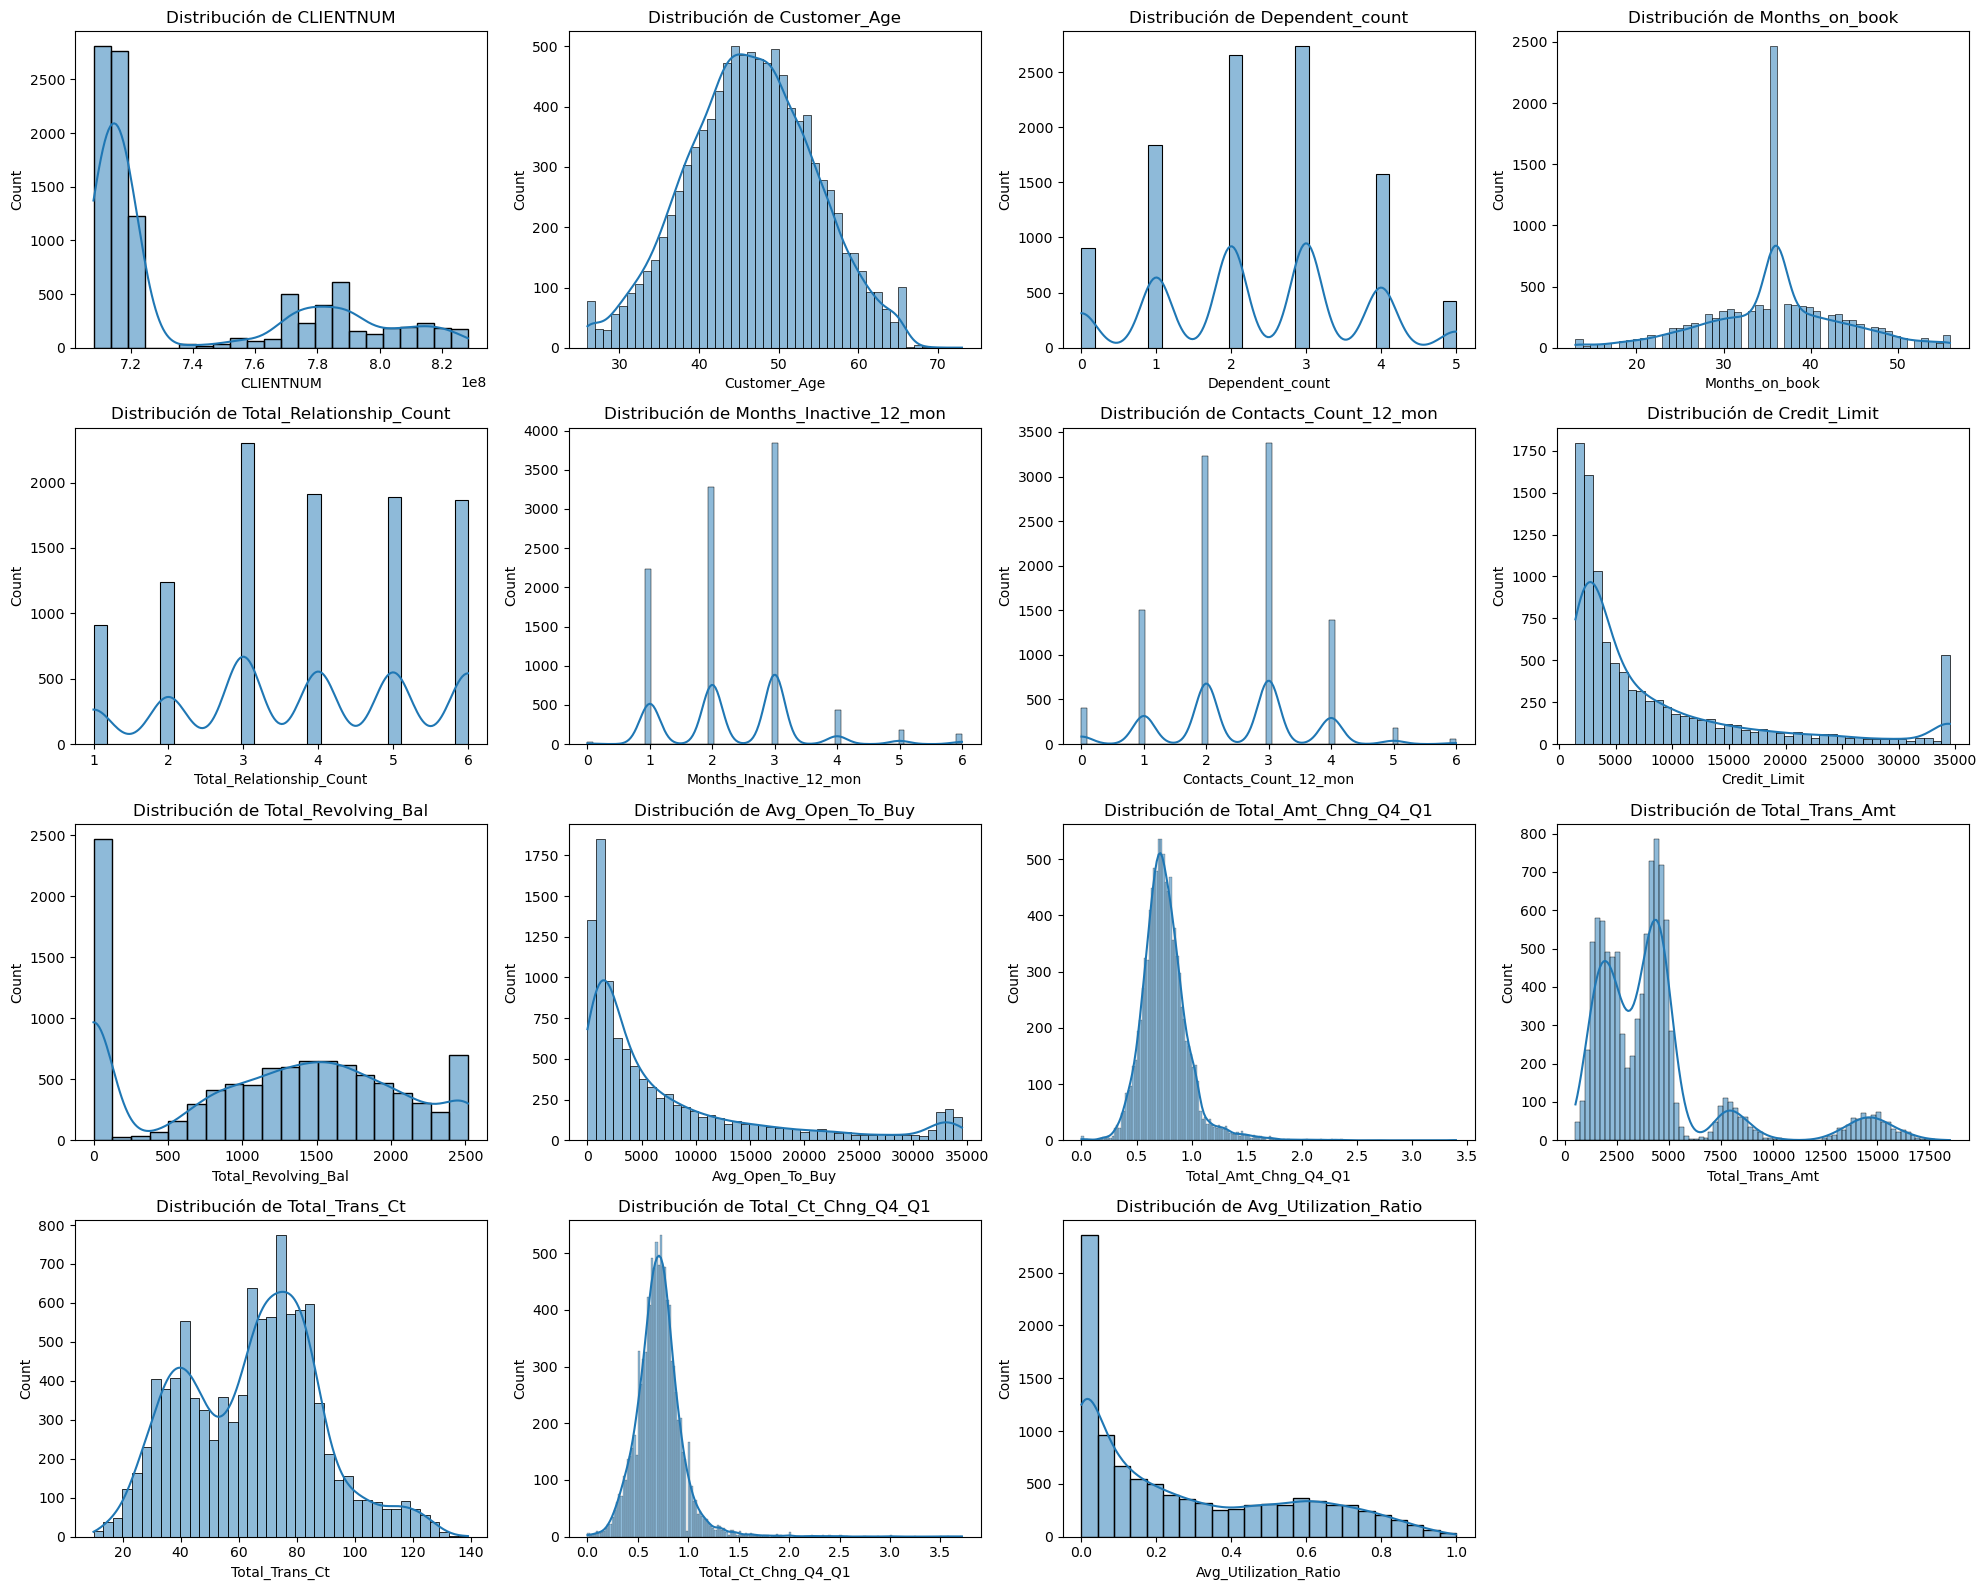

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Distribución de variables categóricas
for col in cat_vars:
    print(f"\nDistribución de {col}:")
    print(df[col].value_counts())

# Distribución de variables numéricas en grupos de 4
cols = list(num_vars)
n = len(cols)
n_cols = 4
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")

# Eliminar ejes vacíos si hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Para acabar esta sección, analizaremos la variable objetivo, Attrition_Flag, para saber cómo de balanceado está el dataset, ya que uno desbalanceado, donde hay muchos más clientes activos que clientes que abandonan, puede afectar al rendimiento de los modelos.

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64 

Porcentaje de clientes que abandonan vs no abandonan:
Attrition_Flag
Existing Customer    83.934038
Attrited Customer    16.065962
Name: proportion, dtype: float64


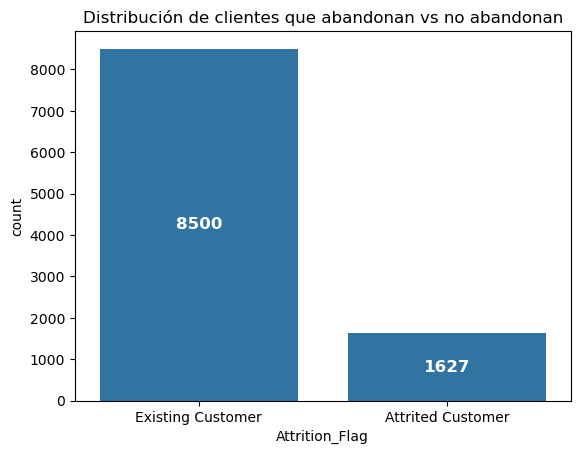

In [12]:
# Mostrar conteo y porcentaje de clientes que abandonan vs no abandonan
print(df['Attrition_Flag'].value_counts(),"\n")

print("Porcentaje de clientes que abandonan vs no abandonan:")
print(df['Attrition_Flag'].value_counts(normalize=True) * 100)

# Gráfica con cantidad de clientes dentro de las barras
ax = sns.countplot(x='Attrition_Flag', data=df)
plt.title("Distribución de clientes que abandonan vs no abandonan")

# Añadir las cantidades dentro de cada barra
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count}', (p.get_x() + p.get_width() / 2, p.get_height() / 2),
                ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.show()


## 1.2 Detección de valores nulos y datos inconsistentes

El siguiente paso fundamental en el análisis de calidad de datos es detectar valores nulos y posibles inconsistencias:

In [13]:
# Detección de valores nulos por columna
df.isnull().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

Como podemos observar, no existen valores nulos explícitos. Sin embargo, esto no significa necesariamente que todos los datos sean correctos o completos. En muchos casos, los valores faltantes pueden aparecer mediante cadenas de texto como "Unknown" o "N/A" en variables categóricas. Para comprobar esto, examinaremos los valores únicos de cada variable categórica:

In [14]:
# Revisión de valores únicos en variables categóricas
for col in cat_vars:
    print(f"\nValores únicos en {col}:")
    print(df[col].unique())



Valores únicos en Attrition_Flag:
['Existing Customer' 'Attrited Customer']

Valores únicos en Gender:
['M' 'F']

Valores únicos en Education_Level:
['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']

Valores únicos en Marital_Status:
['Married' 'Single' 'Unknown' 'Divorced']

Valores únicos en Income_Category:
['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']

Valores únicos en Card_Category:
['Blue' 'Gold' 'Silver' 'Platinum']


Como podemos ver, la variable categórica de Income_Category presenta valores "Unknown". Ante esta falta de información, consideraremos aquellos valores como que no tiene ingresos, esto es, '$0K'.

In [15]:
# Imputar valores 'Unknown' en Income_Category por '$0K'
df['Income_Category'] = df['Income_Category'].replace('Unknown', '$0K')

# Comprobar el resultado
df['Income_Category'].value_counts()

Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
$0K               1112
$120K +            727
Name: count, dtype: int64

En cuanto a datos inconsistentes o poco realistas que podemos tener, especialmente en variables numéricas, son por ejemplo, edades fuera de un rango razonable, saldos negativos extremos o números de productos incoherentes. Para ello, analizaremos los valores mínimos y máximos de cada variable numérica:

In [16]:
# Revisión de rangos en variables numéricas
df[num_vars].min(), df[num_vars].max()

(CLIENTNUM                   708082083.0
 Customer_Age                       26.0
 Dependent_count                     0.0
 Months_on_book                     13.0
 Total_Relationship_Count            1.0
 Months_Inactive_12_mon              0.0
 Contacts_Count_12_mon               0.0
 Credit_Limit                     1438.3
 Total_Revolving_Bal                 0.0
 Avg_Open_To_Buy                     3.0
 Total_Amt_Chng_Q4_Q1                0.0
 Total_Trans_Amt                   510.0
 Total_Trans_Ct                     10.0
 Total_Ct_Chng_Q4_Q1                 0.0
 Avg_Utilization_Ratio               0.0
 dtype: float64,
 CLIENTNUM                   8.283431e+08
 Customer_Age                7.300000e+01
 Dependent_count             5.000000e+00
 Months_on_book              5.600000e+01
 Total_Relationship_Count    6.000000e+00
 Months_Inactive_12_mon      6.000000e+00
 Contacts_Count_12_mon       6.000000e+00
 Credit_Limit                3.451600e+04
 Total_Revolving_Bal         2.5

Aunque a priori no se observan inconsistencias graves en los rangos de las variables numéricas, se analizarán con mayor detalle en las siguientes fases del proyecto.

## 1.3 Análisis de valores atípicos (outliers)

El siguiente paso que haremos es la detección de valores atípicos u outliers. En el contexto de un problema de churn bancario como el nuestro, los valores atípicos son especialmente relevantes, ya que variables como el saldo de la cuenta, el número de transacciones o el límite de crédito pueden presentar distribuciones muy asimétricas.

Para comenzar, visualizaremos cada una de las variables numéricas mediante boxplots:

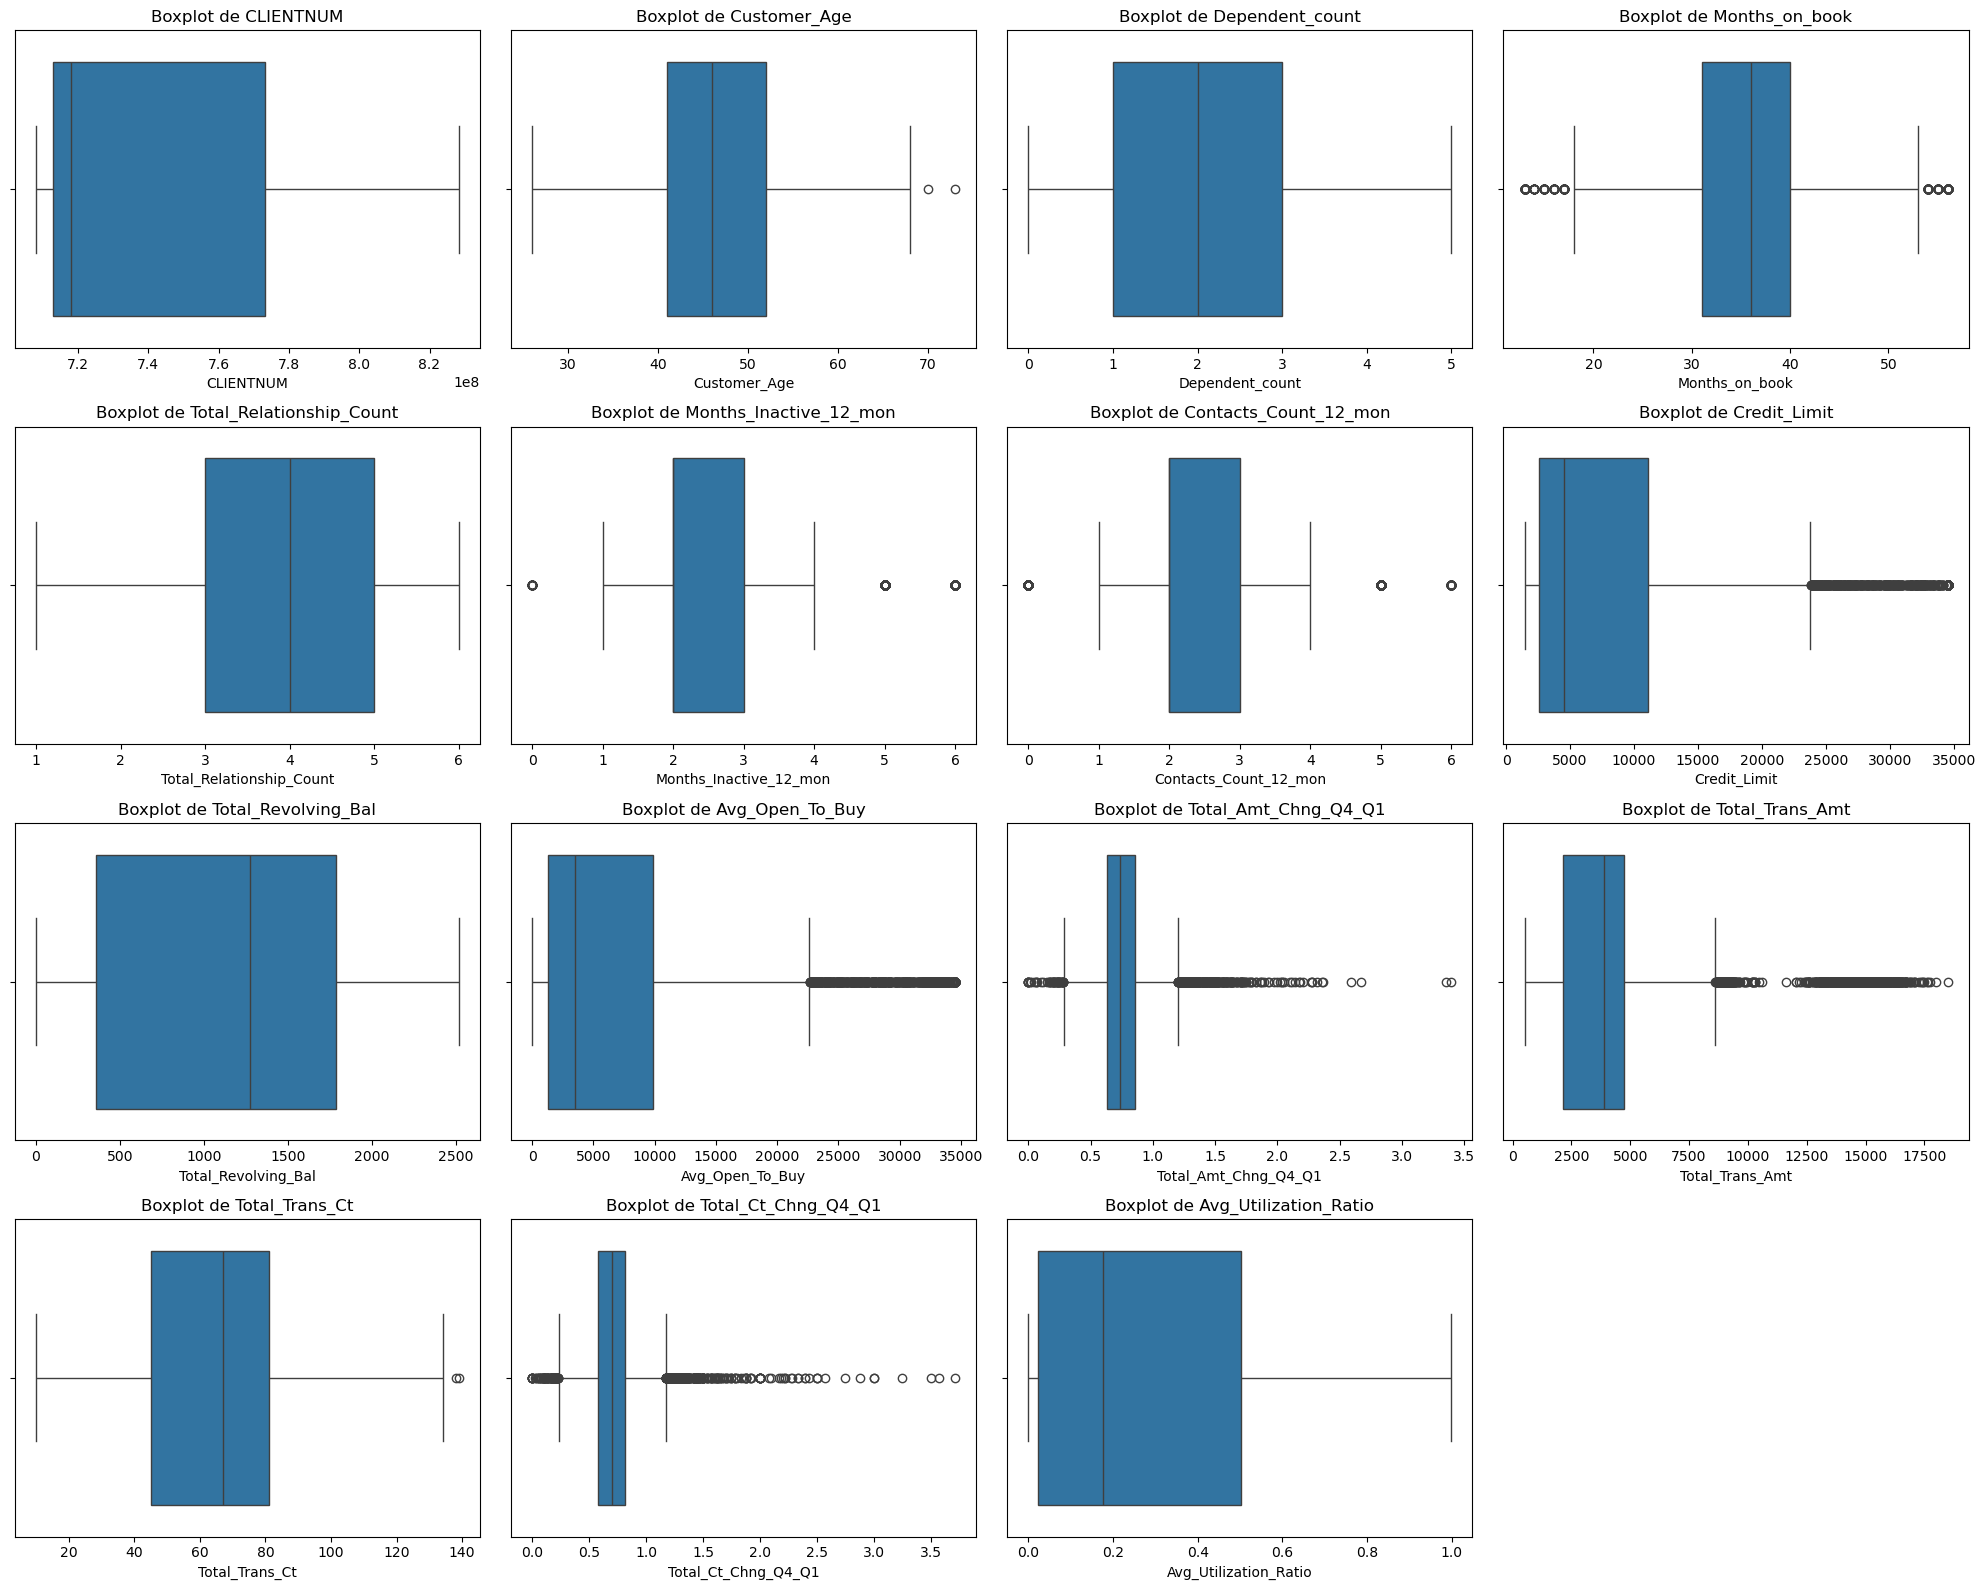

In [18]:
# Boxplots agrupados en subplots de 4 columnas por fila
n = len(num_vars)
n_cols = 4
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot de {col}")

# Eliminar ejes vacíos si hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Además del análisis visual, utilizaremos un enfoque cuantitativo basado en el rango intercuartílico (IQR) para identificar posibles valores atípicos. Este método define como *outliers* aquellos valores que se sitúan por debajo de \( Q_1 - 1.5 \cdot \text{IQR} \) o por encima de \( Q_3 + 1.5 \cdot \text{IQR} \), siendo \( Q_1 \) y \( Q_3 \) el primer y tercer cuartil, respectivamente.  

In [19]:
#Calculamos el número de posibles outliers por variable de la siguiente manera:
outliers = {}

for col in num_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers[col] = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

outliers


{'CLIENTNUM': np.int64(0),
 'Customer_Age': np.int64(2),
 'Dependent_count': np.int64(0),
 'Months_on_book': np.int64(386),
 'Total_Relationship_Count': np.int64(0),
 'Months_Inactive_12_mon': np.int64(331),
 'Contacts_Count_12_mon': np.int64(629),
 'Credit_Limit': np.int64(984),
 'Total_Revolving_Bal': np.int64(0),
 'Avg_Open_To_Buy': np.int64(963),
 'Total_Amt_Chng_Q4_Q1': np.int64(395),
 'Total_Trans_Amt': np.int64(896),
 'Total_Trans_Ct': np.int64(2),
 'Total_Ct_Chng_Q4_Q1': np.int64(396),
 'Avg_Utilization_Ratio': np.int64(0)}

Como podemos observar, encontramos un número elevado de outliers en variables como 'Total_Trans_Amt' o 'Credit_Limit', lo cual no implica necesariamente que sean errores, sino que pueden ser clientes con comportamientos poco comunes pero reales. Entre las posibles estrategias que consideraremos en las fases posteriores para tratar esos posibles outliers son:

- Mantener los outliers si representan comportamientos reales de clientes.

- Aplicar transformaciones (por ejemplo, logarítmicas) para reducir su impacto.

- Eliminar observaciones solo en casos muy extremos y justificados.

# 2️ ANÁLISIS EXPLORATORIO (EDA)

### 2.1 ANÁLISIS DE LA DISTRIBUCIÓN DE LAS VARIABLES Y LA PENETRACIÓN DE LA TARGET

En este punto, analizaremos individualmente cada variable, con el objetivo de poder ver más al detalle la información que aportan, como se distribuyen y como afecta la penetración de la variable Target en cada variable. La variable Target o variable objetivo del análisis, es la variable Attrition_Flag, que recoge la información sobre el estado del cliente.

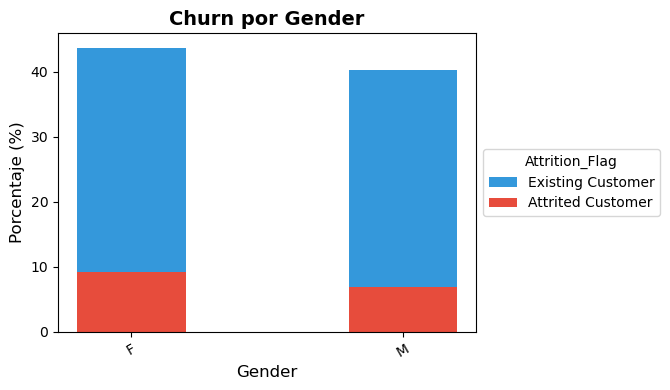

Attrition_Flag,Existing Customer,Attrited Customer
Gender,,
F,43.72%,9.18%
M,40.21%,6.88%
Total,83.93%,16.07%


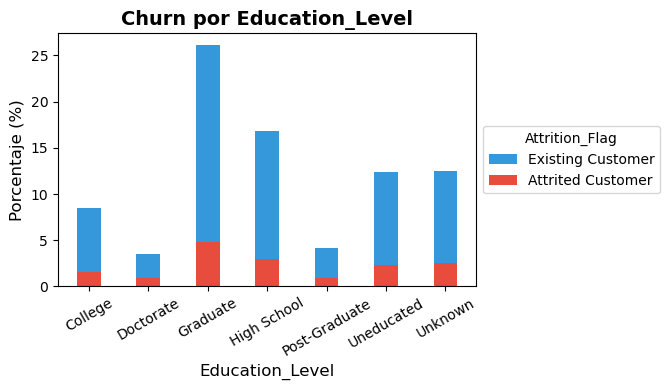

Attrition_Flag,Existing Customer,Attrited Customer
Education_Level,,
College,8.48%,1.52%
Doctorate,3.52%,0.94%
Graduate,26.08%,4.81%
High School,16.86%,3.02%
Post-Graduate,4.19%,0.91%
Uneducated,12.34%,2.34%
Unknown,12.47%,2.53%
Total,83.93%,16.07%


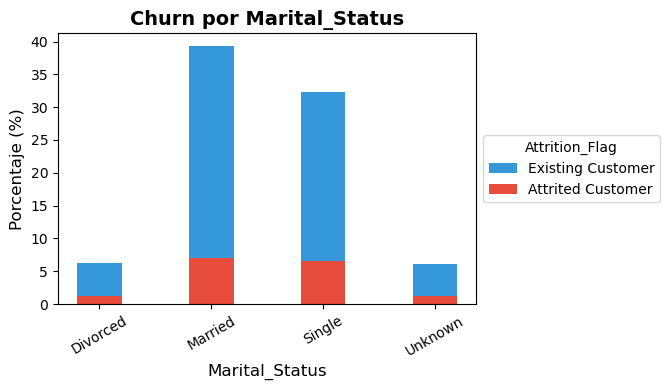

Attrition_Flag,Existing Customer,Attrited Customer
Marital_Status,,
Divorced,6.19%,1.19%
Married,39.28%,7.00%
Single,32.34%,6.60%
Unknown,6.12%,1.27%
Total,83.93%,16.07%


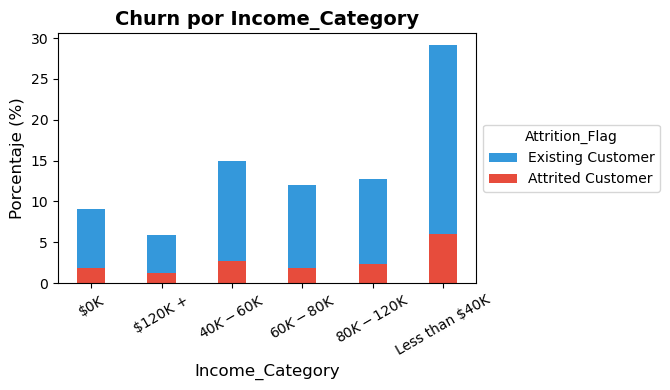

Attrition_Flag,Existing Customer,Attrited Customer
Income_Category,,
$0K,9.13%,1.85%
$120K +,5.93%,1.24%
$40K - $60K,15.00%,2.68%
$60K - $80K,11.98%,1.87%
$80K - $120K,12.77%,2.39%
Less than $40K,29.12%,6.04%
Total,83.93%,16.07%


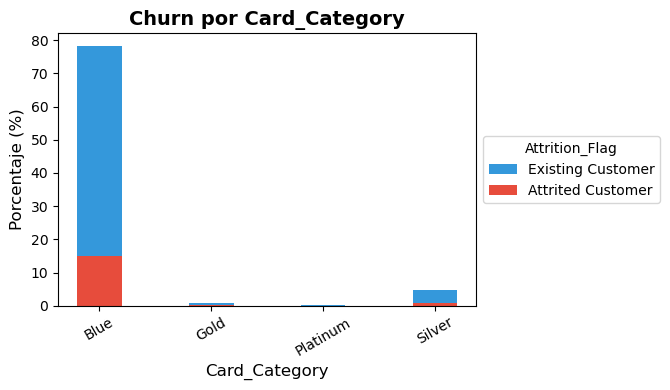

Attrition_Flag,Existing Customer,Attrited Customer
Card_Category,,
Blue,78.18%,15.00%
Gold,0.94%,0.21%
Platinum,0.15%,0.05%
Silver,4.67%,0.81%
Total,83.93%,16.07%


In [91]:
for col in cat_vars:
    if col == 'Attrition_Flag':
        continue

    # Tabla de conteos absolutos por categoría y target
    abs_counts = pd.crosstab(df[col], df['Attrition_Flag'])
    abs_counts = abs_counts[palette.keys()]  # Asegura el orden de las columnas

    # Convertir a porcentaje
    abs_perc = abs_counts.div(len(df)).multiply(100)

    # Gráfico de barras apiladas
    fig, ax = plt.subplots(figsize=(8,4))
    width = 0.4  # Anchura de las barras
    x = range(len(abs_perc))
    bottom = np.zeros(len(abs_perc))
    for i, col_name in enumerate(abs_perc.columns):
        ax.bar(x, abs_perc[col_name], width=width, color=palette[col_name], label=col_name)
        bottom += abs_perc[col_name].values

    ax.set_xticks(x)
    ax.set_xticklabels(abs_perc.index, rotation=30)
    ax.set_ylabel('Porcentaje (%)', fontsize=12)
    ax.set_xlabel(col, fontsize=12)
    ax.set_title("Churn por " f"{col}", fontsize=14, fontweight='bold')
    ax.legend(title='Attrition_Flag', loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

    # Mostrar tabla de porcentajes con suma total por columna
    abs_perc_with_total = abs_perc.copy()
    abs_perc_with_total.loc['Total'] = abs_perc_with_total.sum()
    display(abs_perc_with_total.style.format('{:.2f}%').set_caption(f'Porcentaje de cada grupo de {col}'))
    print("\n")


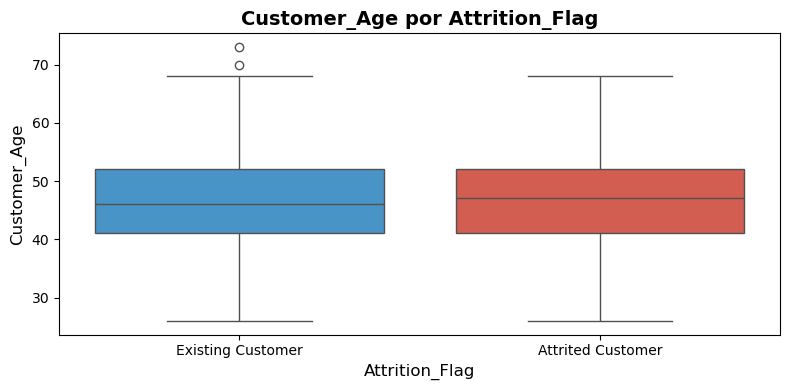

,Media,Mediana,Desv.,Mín,Máx
Attrition_Flag,,,,,
Attrited Customer,46.659496,47.000000,7.665652,26.000000,68.000000
Existing Customer,46.262118,46.000000,8.081157,26.000000,73.000000


La mediana de edad es prácticamente igual entre ambos grupos (47 años en churn, 46 en no churn). La media y la dispersión también son similares, por lo que la edad no parece ser un factor diferenciador relevante para el abandono.


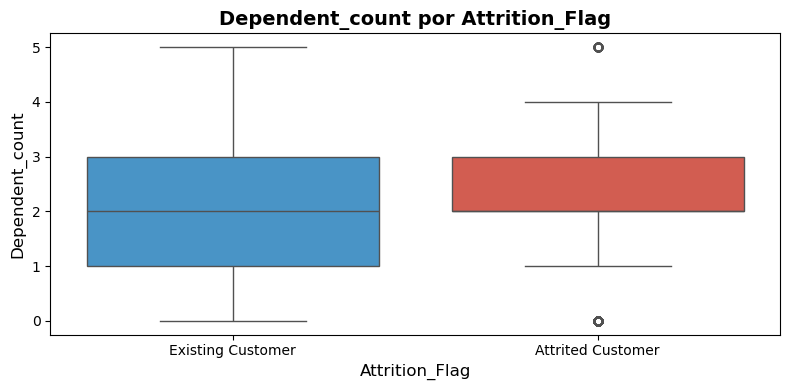

,Media,Mediana,Desv.,Mín,Máx
Attrition_Flag,,,,,
Attrited Customer,2.402581,2.000000,1.275010,0.000000,5.000000
Existing Customer,2.335412,2.000000,1.303229,0.000000,5.000000


La mediana y la media de dependientes son casi iguales (2 en ambos grupos). No se observan diferencias relevantes en la cantidad de dependientes entre clientes que abandonan y los que no.


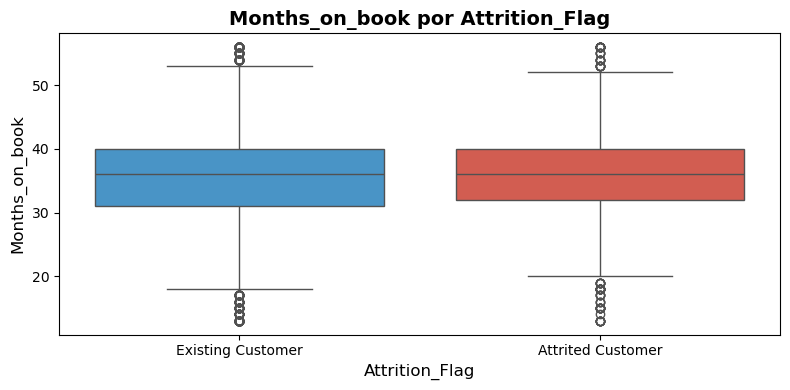

,Media,Mediana,Desv.,Mín,Máx
Attrition_Flag,,,,,
Attrited Customer,36.178242,36.000000,7.796548,13.000000,56.000000
Existing Customer,35.880588,36.000000,8.021810,13.000000,56.000000


La mediana de meses en la compañía es igual (36 en ambos grupos) y la media también. No hay diferencias significativas en la antigüedad entre churn y no churn.


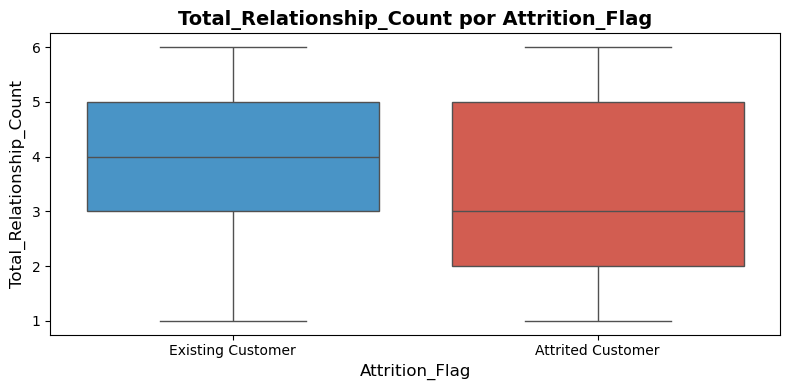

,Media,Mediana,Desv.,Mín,Máx
Attrition_Flag,,,,,
Attrited Customer,3.279656,3.000000,1.577782,1.000000,6.000000
Existing Customer,3.914588,4.000000,1.528949,1.000000,6.000000


La mediana es menor en churn (3 vs 4) y la media también (3.28 vs 3.91). Los clientes que abandonan suelen tener menos productos o relaciones con el banco.


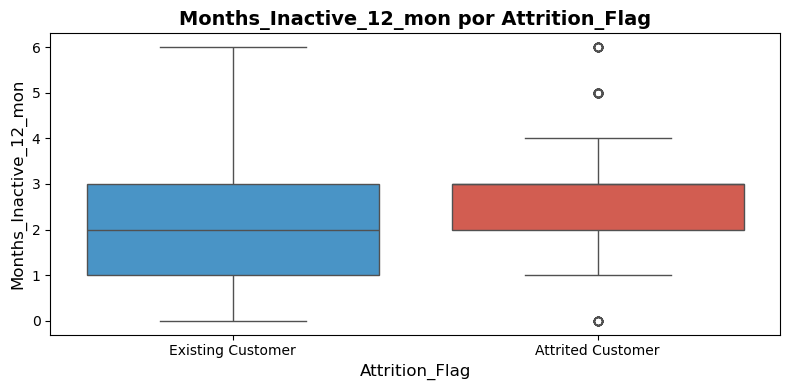

,Media,Mediana,Desv.,Mín,Máx
Attrition_Flag,,,,,
Attrited Customer,2.693301,3.000000,0.899623,0.000000,6.000000
Existing Customer,2.273765,2.000000,1.016741,0.000000,6.000000


La mediana y la media son mayores en churn (3 vs 2 y 2.69 vs 2.27). Los clientes que han estado más inactivos en el último año tienden a abandonar más.


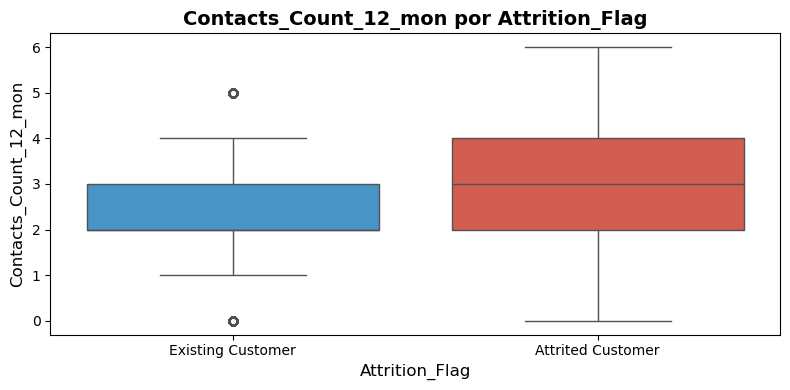

,Media,Mediana,Desv.,Mín,Máx
Attrition_Flag,,,,,
Attrited Customer,2.972342,3.000000,1.090537,0.000000,6.000000
Existing Customer,2.356353,2.000000,1.081436,0.000000,5.000000


La mediana y la media son mayores en churn (3 vs 2 y 2.97 vs 2.36). Los clientes que han contactado más con el banco tienden a abandonar más, posiblemente por problemas o insatisfacción.


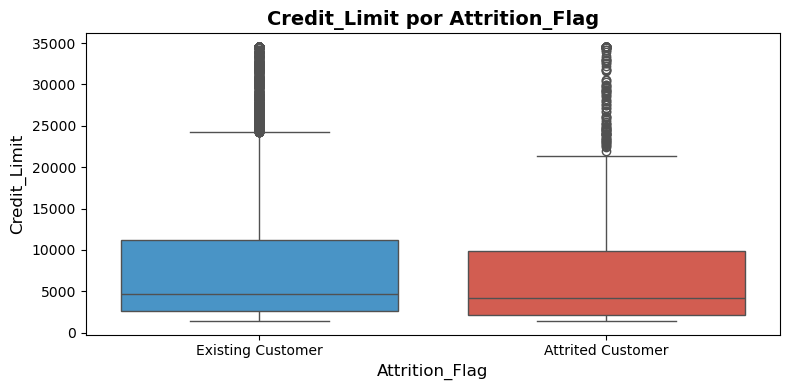

,Media,Mediana,Desv.,Mín,Máx
Attrition_Flag,,,,,
Attrited Customer,8136.039459,4178.000000,9095.334105,1438.300000,34516.000000
Existing Customer,8726.877518,4643.500000,9084.969807,1438.300000,34516.000000


La mediana y la media del límite de crédito son menores en churn (4178 vs 4643.5 y 8136 vs 8726). Los clientes con menor acceso a crédito tienden a abandonar más.


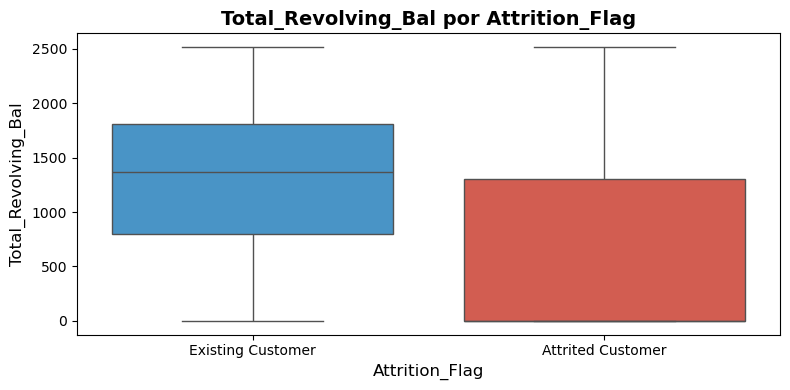

,Media,Mediana,Desv.,Mín,Máx
Attrition_Flag,,,,,
Attrited Customer,672.822987,0.000000,921.385582,0.000000,2517.000000
Existing Customer,1256.604118,1364.000000,757.745354,0.000000,2517.000000


La mediana y la media son mucho menores en churn (0 vs 1364 y 672 vs 1256). Los clientes que abandonan suelen tener menos saldo pendiente.


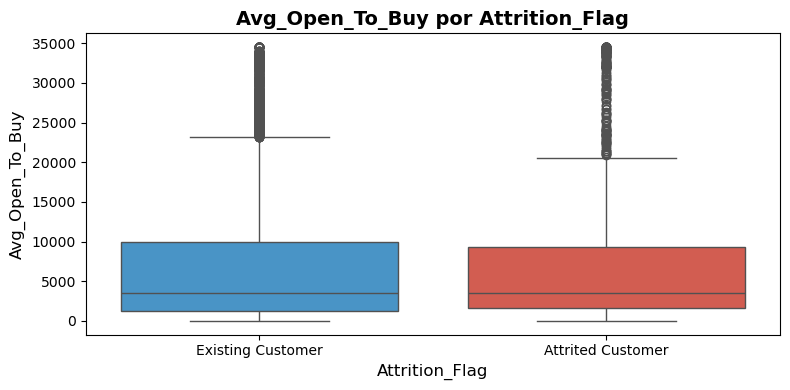

,Media,Mediana,Desv.,Mín,Máx
Attrition_Flag,,,,,
Attrited Customer,7463.216472,3488.000000,9109.208129,3.000000,34516.000000
Existing Customer,7470.273400,3469.500000,9087.671862,15.000000,34516.000000


La mediana y la media son similares en ambos grupos. No parece haber relación clara entre la capacidad de compra y el abandono.


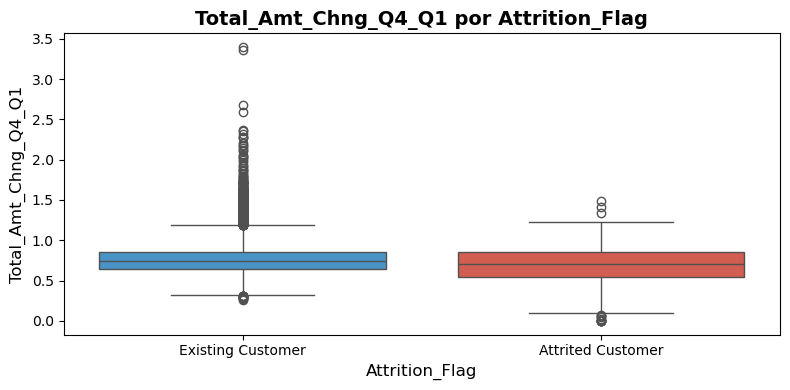

,Media,Mediana,Desv.,Mín,Máx
Attrition_Flag,,,,,
Attrited Customer,0.694277,0.701000,0.214924,0.000000,1.492000
Existing Customer,0.772510,0.743000,0.217783,0.256000,3.397000


La mediana y la media son menores en churn (0.701 vs 0.743 y 0.69 vs 0.77). Los clientes que abandonan tienden a tener menos variación positiva en el monto gastado.


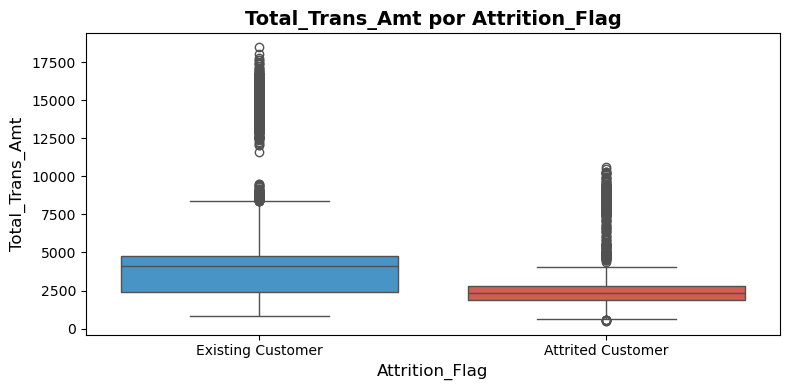

,Media,Mediana,Desv.,Mín,Máx
Attrition_Flag,,,,,
Attrited Customer,3095.025814,2329.000000,2308.227629,510.000000,10583.000000
Existing Customer,4654.655882,4100.000000,3512.772635,816.000000,18484.000000


La mediana y la media son menores en churn (2329 vs 4100 y 3095 vs 4654). Los clientes que gastan menos tienden a abandonar más.


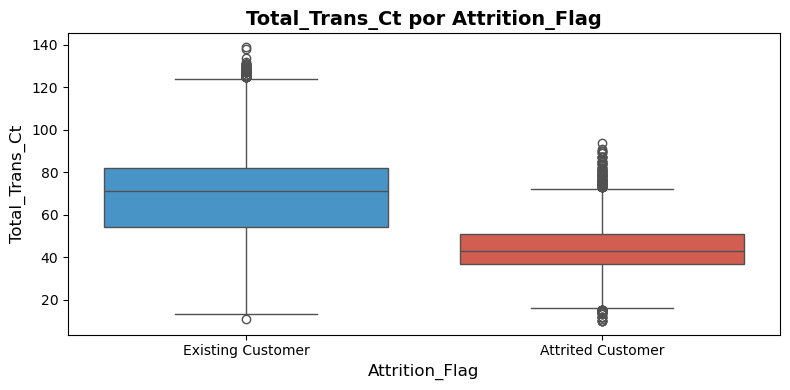

,Media,Mediana,Desv.,Mín,Máx
Attrition_Flag,,,,,
Attrited Customer,44.933620,43.000000,14.568429,10.000000,94.000000
Existing Customer,68.672588,71.000000,22.919011,11.000000,139.000000


La mediana y la media son menores en churn (43 vs 71 y 44.9 vs 68.7). Los clientes con menos transacciones tienden a abandonar más.


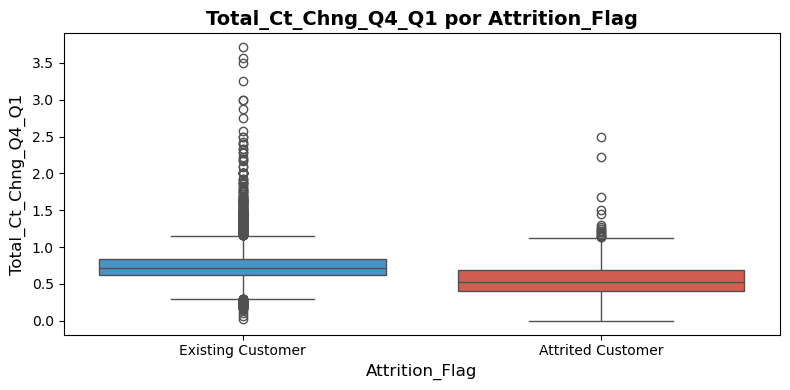

,Media,Mediana,Desv.,Mín,Máx
Attrition_Flag,,,,,
Attrited Customer,0.554386,0.531000,0.226854,0.000000,2.500000
Existing Customer,0.742434,0.721000,0.228054,0.028000,3.714000


La mediana y la media son menores en churn (0.531 vs 0.721 y 0.55 vs 0.74). Los clientes que abandonan tienden a tener menos variación positiva en el número de transacciones.


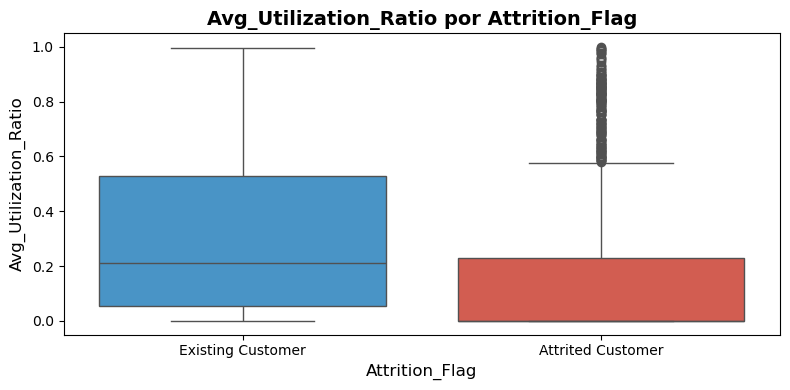

,Media,Mediana,Desv.,Mín,Máx
Attrition_Flag,,,,,
Attrited Customer,0.162475,0.000000,0.264458,0.000000,0.999000
Existing Customer,0.296412,0.211000,0.272568,0.000000,0.994000


La mediana y la media son menores en churn (0 vs 0.211 y 0.16 vs 0.29). Los clientes que abandonan suelen utilizar menos su crédito.


In [ ]:
# Bucle para boxplots y estadísticas con sus interpretaciones de cada variable
interpretaciones = {
    'Customer_Age': "La mediana de edad es prácticamente igual entre ambos grupos (47 años en churn, 46 en no churn). La media y la dispersión también son similares, por lo que la edad no parece ser un factor diferenciador relevante para el abandono.",
    'Dependent_count': "La mediana y la media de dependientes son casi iguales (2 en ambos grupos). No se observan diferencias relevantes en la cantidad de dependientes entre clientes que abandonan y los que no.",
    'Months_on_book': "La mediana de meses en la compañía es igual (36 en ambos grupos) y la media también. No hay diferencias significativas en la antigüedad entre churn y no churn.",
    'Total_Relationship_Count': "La mediana es menor en churn (3 vs 4) y la media también (3.28 vs 3.91). Los clientes que abandonan suelen tener menos productos o relaciones con el banco.",
    'Months_Inactive_12_mon': "La mediana y la media son mayores en churn (3 vs 2 y 2.69 vs 2.27). Los clientes que han estado más inactivos en el último año tienden a abandonar más.",
    'Contacts_Count_12_mon': "La mediana y la media son mayores en churn (3 vs 2 y 2.97 vs 2.36). Los clientes que han contactado más con el banco tienden a abandonar más, posiblemente por problemas o insatisfacción.",
    'Credit_Limit': "La mediana y la media del límite de crédito son menores en churn (4178 vs 4643.5 y 8136 vs 8726). Los clientes con menor acceso a crédito tienden a abandonar más.",
    'Total_Revolving_Bal': "La mediana y la media son mucho menores en churn (0 vs 1364 y 672 vs 1256). Los clientes que abandonan suelen tener menos saldo pendiente.",
    'Avg_Open_To_Buy': "La mediana y la media son similares en ambos grupos. No parece haber relación clara entre la capacidad de compra y el abandono.",
    'Total_Amt_Chng_Q4_Q1': "La mediana y la media son menores en churn (0.701 vs 0.743 y 0.69 vs 0.77). Los clientes que abandonan tienden a tener menos variación positiva en el monto gastado.",
    'Total_Trans_Amt': "La mediana y la media son menores en churn (2329 vs 4100 y 3095 vs 4654). Los clientes que gastan menos tienden a abandonar más.",
    'Total_Trans_Ct': "La mediana y la media son menores en churn (43 vs 71 y 44.9 vs 68.7). Los clientes con menos transacciones tienden a abandonar más.",
    'Total_Ct_Chng_Q4_Q1': "La mediana y la media son menores en churn (0.531 vs 0.721 y 0.55 vs 0.74). Los clientes que abandonan tienden a tener menos variación positiva en el número de transacciones.",
    'Avg_Utilization_Ratio': "La mediana y la media son menores en churn (0 vs 0.211 y 0.16 vs 0.29). Los clientes que abandonan suelen utilizar menos su crédito."
}

for key in interpretaciones.keys(): 
    if key == 'CLIENTNUM':
        continue  # Omitir número de cuenta del cliente

    # Boxplot
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Attrition_Flag', y=key, data=df, hue='Attrition_Flag', 
                palette=palette, dodge=False, legend=False)
    plt.title(f"{key} por Attrition_Flag", fontsize=14, fontweight='bold')
    plt.xlabel('Attrition_Flag', fontsize=12)
    plt.ylabel(key, fontsize=12)
    plt.tight_layout()
    plt.show()

    # Estadísticas
    stats = df.groupby('Attrition_Flag')[key].describe()[['mean','50%','std','min','max']]
    stats = stats.rename(columns={'mean': 'Media', '50%': 'Mediana', 'std': 'Desv.', 'min': 'Mín', 'max': 'Máx'})
    display(stats.style.set_caption(f"Estadísticas de {key} por grupo"))

    # Interpretación
    display(Markdown(f"{interpretaciones[key]}\n"))
    print("\n")